In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib
import os
from sklearn.inspection import permutation_importance
import joblib


In [3]:
df_energy = pd.read_parquet('sense_acute_climate.parquet')

In [4]:
# updated feature list
site_features = [
    'tasmax', 'tasmin', 'tas',
    'HDD', 'CDD', 'tas_lag1', 'tas_lag3', 'tas_7day_mean',
    'extreme_cold', 'heatwave', 'hurs', 'sfcWind', 'rsds',
    'month', 'day_of_week', 'is_weekend'
]

print(df_energy[site_features].isnull().sum())
print(df_energy['consumption'].describe())

tasmax             0
tasmin             0
tas                0
HDD                0
CDD                0
tas_lag1          35
tas_lag3         105
tas_7day_mean      0
extreme_cold       0
heatwave           0
hurs               0
sfcWind            0
rsds               0
month              0
day_of_week        0
is_weekend         0
dtype: int64
count     42584.000000
mean      14833.260836
std       29317.513943
min           0.000000
25%        1537.275001
50%        5244.500023
75%       13527.250051
max      629659.249092
Name: consumption, dtype: float64


## Linear regression
- applied to each site individually, producing R2, RMSE, and coefficient of variation of RMSE CV(RMSE) to allow average and comparison (this is RMSE as a percentage of the site mean).

In [5]:
### cross val linreg:

cv = KFold(n_splits=5, shuffle=True, random_state=0)

for energy in ['elec', 'gas']:
    print(f"\n{energy.upper()}")
    r2_scores = []
    cvrmse_scores = []
    
    for site in df_energy['site_code'].unique():
        site_data = df_energy[(df_energy['site_code'] == site) & 
                              (df_energy['energy_type'] == energy) &
                              (df_energy['consumption'] > 0)].dropna(
                              subset=site_features + ['consumption'])
        
        if len(site_data) < 50:
            continue
            
        X = site_data[site_features]
        y = site_data['consumption']
        
        r2 = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='r2').mean()
        mse = -cross_val_score(LinearRegression(), X, y, cv=cv,
                               scoring='neg_mean_squared_error').mean()
        cvrmse = (np.sqrt(mse) / y.mean()) * 100
        
        r2_scores.append(r2)
        cvrmse_scores.append(cvrmse)
        print(f"  {site}: R²={r2:.3f}, CV(RMSE)={cvrmse:.1f}%")
    
    print(f"\n  Mean R²: {np.mean(r2_scores):.3f}")
    print(f"  Mean CV(RMSE): {np.mean(cvrmse_scores):.1f}%")


ELEC
  R0A06: R²=0.820, CV(RMSE)=8.3%
  R0A07: R²=0.260, CV(RMSE)=13.2%
  R0A09: R²=0.127, CV(RMSE)=26.5%
  R0A66: R²=0.016, CV(RMSE)=60.7%
  RCB05: R²=0.674, CV(RMSE)=6.9%
  RCB07: R²=0.396, CV(RMSE)=14.9%
  RCB55: R²=0.298, CV(RMSE)=45.7%
  RCBCA: R²=0.068, CV(RMSE)=123.1%
  RCBL8: R²=0.746, CV(RMSE)=7.8%
  RCBNH: R²=0.392, CV(RMSE)=29.2%
  RCBP9: R²=0.678, CV(RMSE)=7.4%
  RD130: R²=0.194, CV(RMSE)=100.1%
  RFSDA: R²=0.630, CV(RMSE)=4.7%
  RH801: R²=0.055, CV(RMSE)=49.1%
  RH802: R²=0.518, CV(RMSE)=16.4%
  RH868: R²=0.423, CV(RMSE)=19.7%
  RH880: R²=0.080, CV(RMSE)=66.6%
  RH8K6: R²=0.407, CV(RMSE)=12.1%
  RJC02: R²=0.059, CV(RMSE)=88.4%
  RJC46: R²=0.801, CV(RMSE)=10.3%
  RJN63: R²=0.262, CV(RMSE)=46.9%
  RJN71: R²=0.097, CV(RMSE)=47.7%
  RKB01: R²=0.123, CV(RMSE)=78.9%
  RKB03: R²=0.359, CV(RMSE)=10.4%
  RL131: R²=0.278, CV(RMSE)=29.6%
  RLT01: R²=0.031, CV(RMSE)=129.5%
  RM102: R²=0.124, CV(RMSE)=20.7%
  RM131: R²=0.438, CV(RMSE)=15.7%
  RN325: R²=0.867, CV(RMSE)=14.8%
  RN3G2: R

baseline, gas better than elec.

## Random forest:

RF with hyperparameter tuning and cross-validation

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [3, 5, 10]
}

best_params_rf = {}

for energy in ['elec', 'gas']:
    print(f"\n{energy.upper()}")
    r2_scores = []
    cvrmse_scores = []
    
    for site in df_energy['site_code'].unique():
        site_data = df_energy[(df_energy['site_code'] == site) & 
                              (df_energy['energy_type'] == energy) &
                              (df_energy['consumption'] > 0)].dropna(subset=site_features + ['consumption']).sort_values('datetime')
        
        if len(site_data) > 50:
            X = site_data[site_features]
            y = site_data['consumption']
            
            # grid search to find best params
            rf_grid = GridSearchCV(
                RandomForestRegressor(random_state=0, n_jobs=-1),
                param_grid=param_grid,
                cv=cv,
                scoring='neg_mean_squared_error',
                n_jobs=-1
            )
            rf_grid.fit(X, y)
            
            # evaluate best model
            r2 = cross_val_score(rf_grid.best_estimator_, X, y, cv=cv, scoring='r2').mean()
            mse = -cross_val_score(rf_grid.best_estimator_, X, y, cv=cv, scoring='neg_mean_squared_error').mean()
            rmse = np.sqrt(mse)
            cvrmse = (rmse / y.mean()) * 100
            
            r2_scores.append(r2)
            cvrmse_scores.append(cvrmse)
            best_params_rf[f'{site}_{energy}'] = rf_grid.best_params_
            
            print(f"  {site}: R²={r2:.3f}, CV(RMSE)={cvrmse:.1f}%, params={rf_grid.best_params_}")
    
    print(f"\n  Mean R²: {np.mean(r2_scores):.3f}")
    print(f"  Mean CV(RMSE): {np.mean(cvrmse_scores):.1f}%")


ELEC
  R0A06: R²=0.848, CV(RMSE)=7.6%, params={'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 200}
  R0A07: R²=0.294, CV(RMSE)=12.8%, params={'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 200}
  R0A09: R²=0.149, CV(RMSE)=26.2%, params={'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
  R0A66: R²=0.170, CV(RMSE)=55.7%, params={'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 200}
  RCB05: R²=0.696, CV(RMSE)=6.7%, params={'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 200}
  RCB07: R²=0.414, CV(RMSE)=14.6%, params={'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 200}
  RCB55: R²=0.353, CV(RMSE)=43.8%, params={'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}
  RCBCA: R²=0.234, CV(RMSE)=111.4%, params={'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 100}
  RCBL8: R²=0.765, CV(RMSE)=7.5%, params={'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}
  RCBNH: R²=0.499, CV(RMSE)=26.7%, params={'max_depth':

improvement on linreg. for RF, multicollinearity is not important

In [7]:
# XGB

cv = KFold(n_splits=5, shuffle=True, random_state=0)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]   ### https://xgboost.readthedocs.io/en/stable/parameter.html
}

best_params_xgb = {}

for energy in ['elec', 'gas']:
    print(f"\n{energy.upper()}")
    r2_scores = []
    cvrmse_scores = []
    
    for site in df_energy['site_code'].unique():
        site_data = df_energy[(df_energy['site_code'] == site) & 
                              (df_energy['energy_type'] == energy) &
                              (df_energy['consumption'] > 0)].dropna(subset=site_features + ['consumption']).sort_values('datetime')
        
        if len(site_data) > 50:
            X = site_data[site_features]
            y = site_data['consumption']
            
            xgb_grid = GridSearchCV(
                XGBRegressor(random_state=0, n_jobs=-1, verbosity=0),
                param_grid=param_grid,
                cv=cv,
                scoring='neg_mean_squared_error',
                n_jobs=-1
            )
            xgb_grid.fit(X, y)
            
            r2 = cross_val_score(xgb_grid.best_estimator_, X, y, cv=cv, scoring='r2').mean()
            mse = -cross_val_score(xgb_grid.best_estimator_, X, y, cv=cv, scoring='neg_mean_squared_error').mean()
            rmse = np.sqrt(mse)
            cvrmse = (rmse / y.mean()) * 100
            
            r2_scores.append(r2)
            cvrmse_scores.append(cvrmse)
            best_params_xgb[f'{site}_{energy}'] = xgb_grid.best_params_
            
            print(f"  {site}: R²={r2:.3f}, CV(RMSE)={cvrmse:.1f}%, params={xgb_grid.best_params_}")
    
    print(f"\n  Mean R²: {np.mean(r2_scores):.3f}")
    print(f"  Mean CV(RMSE): {np.mean(cvrmse_scores):.1f}%")


ELEC
  R0A06: R²=0.848, CV(RMSE)=7.6%, params={'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100}
  R0A07: R²=0.310, CV(RMSE)=12.7%, params={'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100}
  R0A09: R²=0.145, CV(RMSE)=26.2%, params={'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100}
  R0A66: R²=0.142, CV(RMSE)=56.7%, params={'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100}
  RCB05: R²=0.691, CV(RMSE)=6.7%, params={'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100}
  RCB07: R²=0.422, CV(RMSE)=14.6%, params={'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100}
  RCB55: R²=0.344, CV(RMSE)=44.1%, params={'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100}
  RCBCA: R²=0.234, CV(RMSE)=111.4%, params={'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimat

### SUMMARY:

MLR: (more affected by multicollinearity)

ELEC: Mean R²: 0.344
      Mean CV(RMSE): 36.7%

GAS: Mean R²: 0.643
     Mean CV(RMSE): 28.5%

RF: 

ELEC: Mean R²: 0.406
     Mean CV(RMSE): 34.7%

GAS: Mean R²: 0.721
     Mean CV(RMSE): 24.4%

XGBoost:

ELEC: Mean R²: 0.408
      Mean CV(RMSE): 34.7%

GAS:   Mean R²: 0.718
       Mean CV(RMSE): 24.1%

# XGB is chosen

In [8]:
# save best params

joblib.dump(best_params_xgb, 'best_params_xgb.pkl')

['best_params_xgb.pkl']

In [9]:
# load
best_params_xgb = joblib.load('best_params_xgb.pkl')


ELEC residuals:
  Mean: 2.2 kWh
  Std: 4518.1 kWh
  % positive: 45.3%

GAS residuals:
  Mean: 4.4 kWh
  Std: 14906.3 kWh
  % positive: 50.6%


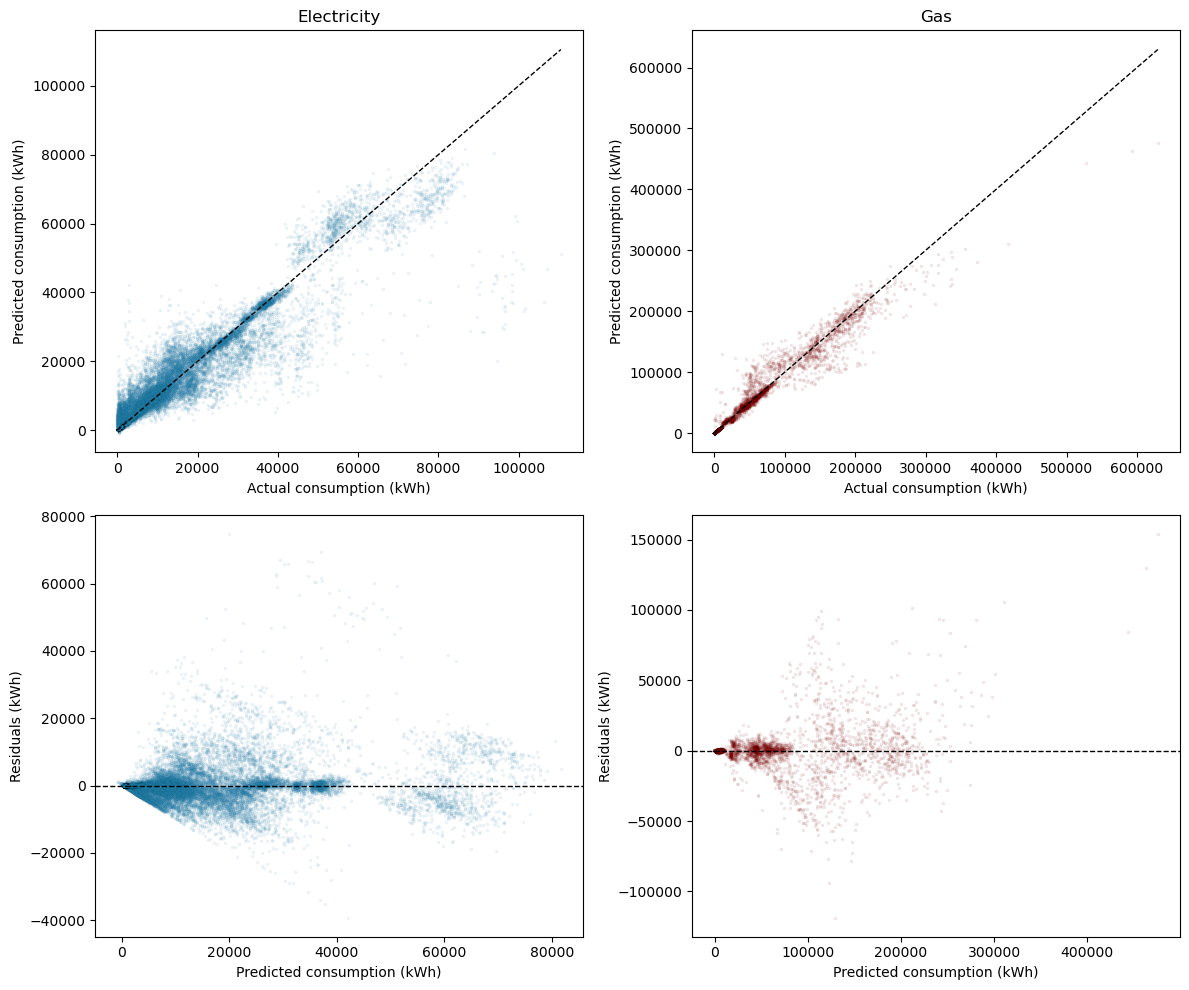

In [11]:
# model criticism: observed vs predicted values and residuals

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

colours = {'elec': '#3195C5', 'gas': 'darkred'}

for col, energy in enumerate(['elec', 'gas']):
    actuals = []
    predicted = []
    
    for site in df_energy['site_code'].unique():
        if f'{site}_{energy}' not in best_params_xgb:
            continue
        
        site_data = df_energy[(df_energy['site_code'] == site) &
                              (df_energy['energy_type'] == energy) &
                              (df_energy['consumption'] > 0)].dropna(subset=site_features)
        
        model = XGBRegressor(
            **best_params_xgb[f'{site}_{energy}'],
            random_state=0, n_jobs=-1
        )
        model.fit(site_data[site_features], site_data['consumption'])
        preds = model.predict(site_data[site_features])
        actuals.extend(site_data['consumption'].values)
        predicted.extend(preds)
    
    actuals = np.array(actuals)
    predicted = np.array(predicted)
    residuals = actuals - predicted
    colour = colours[energy]
    
    ax = axes[0, col]
    ax.scatter(actuals, predicted, alpha=0.1, s=5, color=colour, 
            edgecolors='black', linewidths=0.1)
    max_val = max(actuals.max(), predicted.max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Perfect fit')
    ax.set_xlabel('Actual consumption (kWh)')
    ax.set_ylabel('Predicted consumption (kWh)')
    
    ax = axes[1, col]
    ax.scatter(predicted, residuals, alpha=0.1, s=5, color=colour,
           edgecolors='black', linewidths=0.1)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted consumption (kWh)')
    ax.set_ylabel('Residuals (kWh)')
    
    print(f"\n{energy.upper()} residuals:")
    print(f"  Mean: {residuals.mean():.1f} kWh")
    print(f"  Std: {residuals.std():.1f} kWh")
    print(f"  % positive: {(residuals > 0).mean()*100:.1f}%")

axes = axes.ravel()
axes[0].set_title('Electricity')
axes[1].set_title('Gas')
plt.tight_layout()
plt.show()

# bias - underpredicting high consumption values
# RF averages across many decision trees, compresses extreme values towards mean


ELEC median permutation importances:


C:\Users\alexd\AppData\Local\Temp\ipykernel_28048\602232448.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(importance_array[:, order],


,variable,median_permutation_importance
6,month,0.156722
7,day_of_week,0.143007
0,tasmax,0.132761
2,tas,0.130076
5,rsds,0.120913
3,hurs,0.077875
1,tasmin,0.066205
4,sfcWind,0.051198
8,is_weekend,0.000000



GAS median permutation importances:


C:\Users\alexd\AppData\Local\Temp\ipykernel_28048\602232448.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(importance_array[:, order],


,variable,median_permutation_importance
2,tas,0.310978
0,tasmax,0.213171
6,month,0.116734
1,tasmin,0.058774
5,rsds,0.049896
3,hurs,0.046375
4,sfcWind,0.024681
7,day_of_week,0.010576
8,is_weekend,0.000000


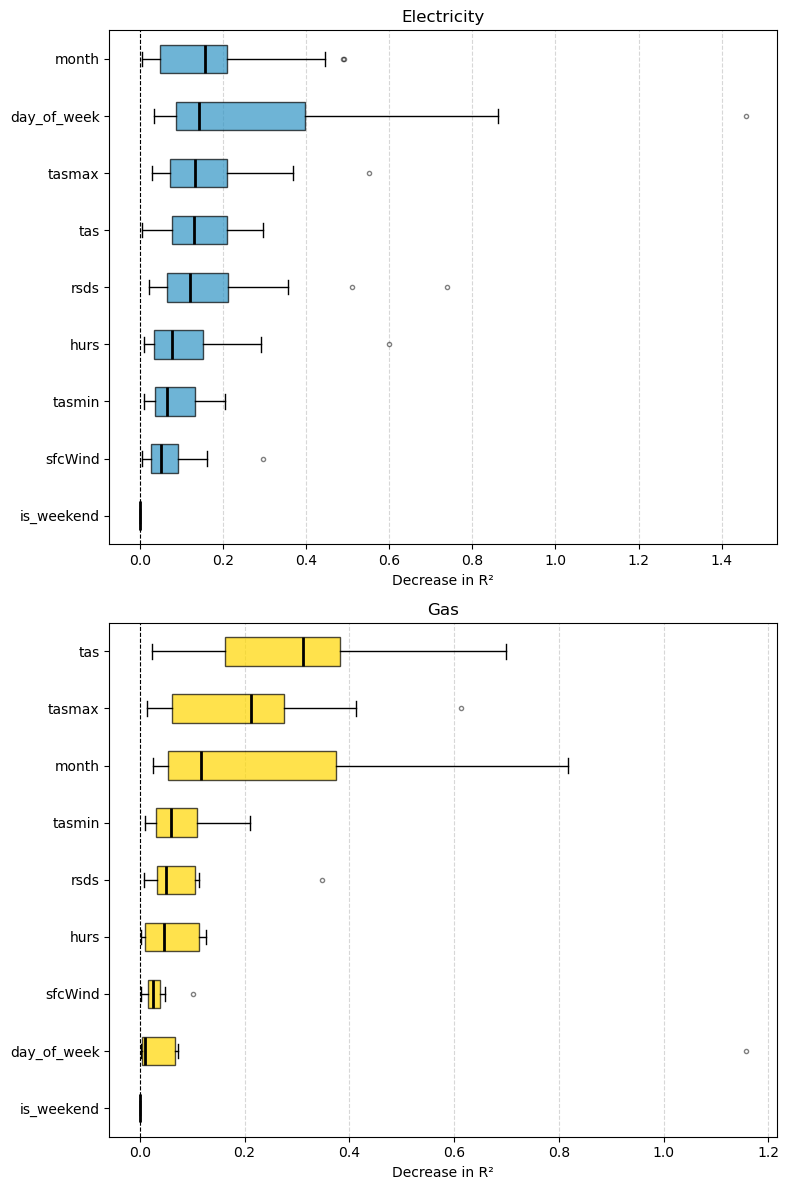

In [12]:
### PFI

fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, energy in zip(axes, ['elec', 'gas']):
    all_importances = []
    
    for site in df_energy['site_code'].unique():
        site_data = df_energy[(df_energy['site_code'] == site) &
                              (df_energy['energy_type'] == energy) &
                              (df_energy['consumption'] > 0)].dropna(
                              subset=site_features + ['consumption'])
        
        if len(site_data) < 50:
            continue
        
        non_engineered_features = [
                    f for f in site_features
                    if f not in [
                    'HDD', 'CDD', 'tas_lag1', 'tas_lag3', 'tas_7day_mean', 'heatwave', 'extreme_cold'
                    ]
        ]

        X = site_data[non_engineered_features]
        y = site_data['consumption']
        
        model = XGBRegressor(
            **best_params_xgb[f'{site}_{energy}'],
            random_state=0, n_jobs=-1
        )
        model.fit(X, y)
        
        result = permutation_importance(model, X, y, n_repeats=5,
                                        random_state=0, n_jobs=-1)
        all_importances.append(result.importances_mean)
    
    importance_array = np.array(all_importances)
    
    # sort by median importance
    medians = np.median(importance_array, axis=0)
    order = np.argsort(medians)
    
    ax.boxplot(importance_array[:, order], 
               vert=False,
               labels=[non_engineered_features[i] for i in order],
               patch_artist=True,
               boxprops=dict(facecolor='#3195C5' if energy == 'elec' else 'gold', alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.5))
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Decrease in R²')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    median_table = pd.DataFrame({
        'variable': non_engineered_features,
        'median_permutation_importance': medians
    }).sort_values('median_permutation_importance', ascending=False)

    print(f"\n{energy.upper()} median permutation importances:")
    display(median_table)

axes[0].set_title('Electricity')
axes[1].set_title('Gas')

plt.tight_layout()
plt.show()
    

In [15]:
### save models

os.makedirs('trained_models', exist_ok=True)

for energy in ['elec', 'gas']:
    for site in df_energy['site_code'].unique():
        
        site_hist = df_energy[(df_energy['site_code'] == site) &
                              (df_energy['energy_type'] == energy) &
                              (df_energy['consumption'] > 0)].dropna(
                              subset=site_features + ['consumption'])
        
        if len(site_hist) < 50:
            continue
        
        X_train = site_hist[site_features]
        y_train = site_hist['consumption']
        
        params = best_params_xgb.get(f'{site}_{energy}')
        if params is None:
            continue

        model = XGBRegressor(**params, random_state=0, n_jobs=-1)
        model.fit(X_train, y_train)
        
        joblib.dump(model, f'trained_models/{site}_{energy}_xgb.pkl')
        print(f"Saved: {site}_{energy}")

print("All models saved")

Saved: R0A06_elec
Saved: R0A07_elec
Saved: R0A09_elec
Saved: R0A66_elec
Saved: RCB05_elec
Saved: RCB07_elec
Saved: RCB55_elec
Saved: RCBCA_elec
Saved: RCBL8_elec
Saved: RCBNH_elec
Saved: RCBP9_elec
Saved: RD130_elec
Saved: RFSDA_elec
Saved: RH801_elec
Saved: RH802_elec
Saved: RH868_elec
Saved: RH880_elec
Saved: RH8K6_elec
Saved: RJC02_elec
Saved: RJC46_elec
Saved: RJN63_elec
Saved: RJN71_elec
Saved: RKB01_elec
Saved: RKB03_elec
Saved: RL131_elec
Saved: RLT01_elec
Saved: RM102_elec
Saved: RM131_elec
Saved: RN325_elec
Saved: RN3G2_elec
Saved: RQ301_elec
Saved: RQXM1_elec
Saved: RXN01_elec
Saved: RXN02_elec
Saved: R0A01_gas
Saved: R0A06_gas
Saved: RD130_gas
Saved: RH801_gas
Saved: RH868_gas
Saved: RH8K6_gas
Saved: RL131_gas
Saved: RQXM1_gas
Saved: RXN02_gas
All models saved


In [58]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)

# get postcodes
site_info = df_energy.drop_duplicates('site_code')[['site_code', 'site_name', 'postcode', 
                                                      'integrated_care_board', 'acute_type']]

results = []

for energy in ['elec', 'gas']:
    for site in df_energy['site_code'].unique():
        
        site_data = df_energy[(df_energy['site_code'] == site) &
                              (df_energy['energy_type'] == energy) &
                              (df_energy['consumption'] > 0)].dropna(
                              subset=site_features + ['consumption']).sort_values('datetime')
        
        if len(site_data) < 50:
            continue
        
        key = f'{site}_{energy}'
        if key not in best_params_xgb:
            continue
        
        X = site_data[site_features]
        y = site_data['consumption']
        
        params = best_params_xgb[key]
        model = XGBRegressor(**params, random_state=0, n_jobs=-1)
        
        r2 = cross_val_score(model, X, y, cv=cv, scoring='r2').mean()
        mse = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error').mean()
        rmse = np.sqrt(mse)
        cvrmse = (rmse / y.mean()) * 100
        
        info = site_info[site_info['site_code'] == site].iloc[0]
        date_range = site_data['datetime'].agg(['min', 'max'])
        
        results.append({
            'Site name': info['site_name'],
            'Site code': site,
            'Postcode': info['postcode'],
            'Integrated care board': info['integrated_care_board'],
            'Acute type': info['acute_type'],
            'Energy type': energy.upper(),
            'Start date': date_range['min'].date(),
            'End date': date_range['max'].date(),
            'N observations': len(site_data),
            'R²': round(r2, 3),
            'CV(RMSE) (%)': round(cvrmse, 1),
            'RMSE (kWh)': round(rmse, 1),
            'Mean consumption (kWh)': round(y.mean(), 1),
            'n_estimators': params['n_estimators'],
            'max_depth': params['max_depth'],
            'learning_rate': params['learning_rate'],
            'min_child_weight': params['min_child_weight']
        })

results_df = pd.DataFrame(results).sort_values(['Energy type', 'Site name'])

results_df.to_excel('xgb_per_site_results.xlsx', index=False)
print(f"Saved xgb_per_site_results.xlsx ({len(results_df)} rows)")
display(results_df)

Saved xgb_per_site_results.xlsx (43 rows)


,Site name,Site code,Postcode,Integrated care board,Acute type,Energy type,Start date,End date,N observations,R²,CV(RMSE) (%),RMSE (kWh),Mean consumption (kWh),n_estimators,max_depth,learning_rate,min_child_weight
30,Birmingham Childrens Hospital,RQ301,B4 6NH,NHS BIRMINGHAM AND SOLIHULL ICB,SPECIALIST,ELEC,2023-02-05,2026-05-08,1187,0.786,3.3,219.5,6575.7,100,3,0.05,5
9,Bridlington Hospital,RCBNH,YO16 4QP,NHS HUMBER AND NORTH YORKSHIRE ICB,TEACHING,ELEC,2024-03-31,2026-05-08,769,0.512,26.3,1210.4,4594.0,200,3,0.05,3
12,Chesterfield Royal Hospital,RFSDA,S44 5BL,NHS DERBY AND DERBYSHIRE ICB,SMALL,ELEC,2022-12-10,2026-05-08,1243,0.673,4.4,1608.8,36193.7,200,3,0.05,3
32,Chorley And South Ribble District General Hosp...,RXN01,PR7 1PP,NHS LANCASHIRE AND SOUTH CUMBRIA ICB,TEACHING,ELEC,2023-02-05,2026-05-08,1188,0.142,39.5,2813.4,7113.9,100,5,0.10,5
20,Congleton War Memorial Hospital,RJN63,CW12 3AR,NHS CHESHIRE AND MERSEYSIDE ICB,SMALL,ELEC,2024-01-30,2026-05-08,830,0.248,47.5,261.4,550.6,100,3,0.05,5
27,Cromer Hospital,RM131,NR27 0BQ,NHS NORFOLK AND WAVENEY ICB,TEACHING,ELEC,2023-02-05,2026-05-08,1187,0.475,15.2,278.6,1838.2,200,3,0.05,1
25,George Eliot Hospital,RLT01,CV10 7DJ,NHS COVENTRY AND WARWICKSHIRE ICB,SMALL,ELEC,2023-02-05,2026-05-08,1167,0.096,124.9,8882.9,7110.8,100,5,0.05,5
28,Great Western Hospital,RN325,SN3 6BB,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...",MEDIUM,ELEC,2023-02-05,2026-05-08,1142,0.880,14.1,85.8,608.8,200,3,0.05,5
14,Heavitree Hospital,RH802,EX1 2ED,NHS DEVON ICB,LARGE,ELEC,2022-12-10,2026-05-08,1237,0.485,16.7,503.6,3008.5,100,3,0.05,5
31,Homerton University Hospital,RQXM1,E9 6SR,NHS NORTH EAST LONDON ICB,TEACHING,ELEC,2023-02-05,2026-05-08,1187,0.272,11.9,3050.3,25577.2,200,5,0.05,1
